In [1]:
# --- Colab bootstrap -------------------------------------------------------
import os, sys
if not (os.path.isdir('../thermo') or os.path.isdir('thermo')):
    !rm -rf /tmp/cbet6e
    !git clone -q --depth 1 https://github.com/emfurst/cbet6e.git /tmp/cbet6e
    !cp -r /tmp/cbet6e/code/thermo /tmp/cbet6e/code/data .
    sys.path.insert(0, '.')
# ---------------------------------------------------------------------------


# Testing a correlation against 160 printed numbers (Table 11.4-1)

Table 11.4-1 lists five properties of 32 organic chemicals, herbicides and pesticides:
$\log_{10}K_{\rm OW}$, vapor pressure, Henry's constant, melting point and aqueous
solubility. Nothing in Section 11.4 does anything with it. This notebook does two things
with it, and both are the book's own suggestions.

**First, Problem 11.4-5's consistency test.** The problem asks the reader to show that
for a sparingly soluble species

$$H_i = \frac{P_i^{\rm vap}}{C_i^{\rm sat}}$$

and then to test it on five substances from the table. Three of the five columns are
therefore not independent, and running the test on all 32 rows turns the table into a
check on itself.

**Second, Eq. 11.4-13's correlation.** The paragraph after that equation states that knowing any one of the infinite-dilution activity coefficient, the octanol-water
partition coefficient and the aqueous solubility lets the other two be estimated. The
table prints two of the three, so the correlation can be tested 32 times. The book never
does it.

**What the table does not carry, and what has to be supplied.** There is no molecular
weight column, and both tests need one -- $C^{\rm sat}$ in mol/m³ comes from a
solubility in mg/L only through a molecular weight. The values below are computed from
each substance's formula, which is a lookup rather than a fit; every one is stated so it
can be checked.

SIS is Stanley I. Sandler, *Chemical, Biochemical, and Engineering Thermodynamics*.

Eric Furst
August 2026

In [2]:

import sys; sys.path.insert(0, "..")
import numpy as np
import matplotlib.pyplot as plt

from thermo.charts import use_book_style
from thermo.partition import kow_from_gamma
from thermo.lle import gamma_from_solubility

use_book_style()

MW_WATER = 18.015

# Table 11.4-1 as printed, with a molecular weight from each formula added.
#   name, formula, MW, log10 K_OW, P^vap (kPa at 25 C), H (bar m^3/mol),
#   melting point (C), aqueous solubility (mg/L)
TABLE = [
    ("Acrolein",              "C3H4O",       56.06, -0.10, 35.3,     4.5e-6,   -88.0, 2.08e5),
    ("Aldicarb",              "C7H14N2O2S", 190.26,  1.13, 1.3e-5,   4.23e-9,   99.0, 6.0e3),
    ("Aniline",               "C6H7N",       93.13,  0.90, 0.065,    0.138,     -6.3, 3.607e4),
    ("1,3-Butadiene",         "C4H6",        54.09,  1.99, 281.0,   20.6,     -108.9, 735.0),
    ("Chlorobenzene",         "C6H5Cl",     112.56,  2.80, 1.38,     3.82e-3,  -45.6, 484.0),
    ("Chlordane",             "C10H6Cl8",   409.78,  5.54, 1.31e-6,  4.92e-5,  107.0, 0.1),
    ("2-Chlorophenol",        "C6H5ClO",    128.56,  2.15, 0.189,    5.7e-7,     9.3, 2.8e4),
    ("2-Cresol",              "C7H8O",      108.14,  1.95, 0.041,    1.6e-6,    30.9, 30.8),
    ("2,4-D",                 "C8H6Cl2O3",  221.04,  2.81, 8.0e-8,   1.39e-10, 140.5, 690.0),
    ("1,2-Dichlorobenzene",   "C6H4Cl2",    147.00,  3.38, 0.196,    1.2e-3,   -17.0, 156.0),
    ("1,4-Dichlorobenzene",   "C6H4Cl2",    147.00,  3.52, 0.235,    1.5e-3,    53.1, 80.0),
    ("Dieldrin",              "C12H8Cl6O",  380.91,  4.32, 5.00e-7,  5.9e-5,   175.0, 0.17),
    ("Ethylbenzene",          "C8H10",      106.17,  3.15, 1.27,     8.19e-3,  -95.0, 152.0),
    ("Formaldehyde",          "CH2O",        30.03,  0.35, 517.6,    3.31e-7,  -92.0, 5.5e5),
    ("Heptachlor",            "C10H5Cl7",   373.32,  5.27, 5.3e-5,   1.50e-3,   95.0, 0.18),
    ("Hexachlorobenzene",     "C6Cl6",      284.78,  5.31, 2.5e-6,   1.3e-3,   231.0, 6.2e-3),
    ("Hexachloroethane",      "C2Cl6",      236.74,  3.82, 0.028,    2.8e-3,   187.0, 50.0),
    ("Lindane",               "C6H6Cl6",    290.83,  3.61, 7.43e-6,  2.96e-6,  112.5, 7.3),
    ("Malathion",             "C10H19O6PS2",330.36,  2.36, 1.1e-6,   2.8e-8,     2.9, 143.0),
    ("Methyl bromide",        "CH3Br",       94.94,  1.19, 217.7,    6.32e-3,  -93.7, 1.52e4),
    ("Methyl chloride",       "CH3Cl",       50.49,  0.91, 570.0,    9.77e-3,  -97.0, 5235.0),
    ("Naphthalene",           "C10H8",      128.17,  3.30, 3.68e-2,  4.3e-4,    80.2, 31.0),
    ("Nitrobenzene",          "C6H5NO2",    123.11,  1.85, 0.020,    2.47e-5,    5.7, 1.9e3),
    ("3-Nitrophenol",         "C6H5NO3",    139.11,  2.00, 0.10,     1.03e-7,   97.0, 1.35e4),
    ("Parathion",             "C10H14NO5PS",291.26,  3.83, 1.29e-6,  5.73e-7,    6.0, 6.5),
    ("Phenol",                "C6H6O",       94.11,  1.46, 0.0466,   4.02e-7,   41.0, 8.7e4),
    ("Silvex",                "C9H7Cl3O3",  269.51,  3.41, 6.9e-7,   1.33e-8,  180.0, 140.0),
    ("Styrene",               "C8H8",       104.15,  2.95, 0.88,     2.85e-3,  -30.6, 310.0),
    ("2,4,5-T",               "C8H5Cl3O3",  255.48,  3.13, 1.0e-7,   8.80e-9,  153.0, 278.0),
    ("1,2,4-Trichlorobenzene","C6H3Cl3",    181.45,  4.10, 0.053,    1.44e-3,   17.0, 48.8),
    ("2,4,5-Trichlorophenol", "C6H3Cl3O",   197.45,  3.72, 2.9e-3,   5.90e-6,   67.0, 982.0),
    ("2,4,6-Trichlorophenol", "C6H3Cl3O",   197.45,  3.69, 1.12e-3,  6.22e-8,   69.0, 900.0),
]

name = np.array([r[0] for r in TABLE])
MW = np.array([r[2] for r in TABLE])
log_kow = np.array([r[3] for r in TABLE])
P_kPa = np.array([r[4] for r in TABLE])
H_printed = np.array([r[5] for r in TABLE])
T_melt = np.array([r[6] for r in TABLE])
solubility = np.array([r[7] for r in TABLE])       # mg/L

# Two derived quantities, both needed by both tests.
C_sat = solubility * 1e-3 / MW * 1e3               # mol/m^3
x_sat = (solubility * 1e-3 / MW) / (solubility * 1e-3 / MW + 1000.0 / MW_WATER)

print(f"  {len(TABLE)} substances, 5 printed columns = {5*len(TABLE)} printed numbers")
print(f"  liquid at 25 C: {(T_melt < 25).sum()}, solid: {(T_melt >= 25).sum()}")
print(f"  aqueous mole fraction at saturation spans"
      f" {x_sat.min():.1e} to {x_sat.max():.2f}")

  32 substances, 5 printed columns = 160 printed numbers
  liquid at 25 C: 15, solid: 17
  aqueous mole fraction at saturation spans 3.9e-10 to 0.25



## Problem 11.4-5: three columns that cannot disagree

$H = P^{\rm vap}/C^{\rm sat}$ follows from Henry's law and the definition of saturation,
and it holds only where the solute is dilute enough for its activity coefficient to be
constant between the two states. So the test has a domain, and the table's own solubility column shows where that is: acrolein and formaldehyde are 6 % and 25 % of the
solution by mole fraction, and nothing in this test applies to them.

A compilation's Henry's constants are measurements rather than quotients, so agreement
within a factor of two or three is all that should be expected. What the test is good
for is finding cells that are wrong by *powers of ten*.

In [3]:

H_identity = (P_kPa / 100.0) / C_sat               # bar m^3/mol
ratio = H_printed / H_identity
dilute = x_sat < 1e-2

order = np.argsort(ratio)
print(f"  {'substance':24s} {'x_sat':>9s} {'H printed':>10s} {'P/C':>10s} {'ratio':>9s}")
for i in order:
    mark = ""
    if not dilute[i]:
        mark = "   too soluble for this test"
    elif ratio[i] > 4 or ratio[i] < 0.25:
        mark = f"   off by 10^{round(np.log10(ratio[i])):+d}"
    print(f"  {name[i]:24s} {x_sat[i]:9.1e} {H_printed[i]:10.3g} {H_identity[i]:10.3g}"
          f" {ratio[i]:9.3g}{mark}")

good = ratio[dilute]
print(f"\n  Of the {dilute.sum()} rows the test applies to:")
print(f"    geometric mean ratio {np.exp(np.mean(np.log(good))):.2f}")
print(f"    within a factor of 2 of 1: {np.sum((good > 0.5) & (good < 2))}")
print(f"    within a factor of 3 of 1: {np.sum((good > 1/3) & (good < 3))}")

  substance                    x_sat  H printed        P/C     ratio
  2-Cresol                   5.1e-06    1.6e-06    0.00144   0.00111   off by 10^-3
  Formaldehyde               2.5e-01   3.31e-07   0.000283   0.00117   too soluble for this test
  3-Nitrophenol              1.7e-03   1.03e-07   1.03e-05      0.01   off by 10^-2
  2,4,6-Trichlorophenol      8.2e-05   6.22e-08   2.46e-06    0.0253   off by 10^-2
  Acrolein                   6.3e-02    4.5e-06   9.51e-05    0.0473   too soluble for this test
  2-Chlorophenol             3.9e-03    5.7e-07   8.68e-06    0.0657   off by 10^-1
  Methyl chloride            1.9e-03    0.00977      0.055     0.178   off by 10^-1
  Naphthalene                4.4e-06    0.00043    0.00152     0.283
  1,4-Dichlorobenzene        9.8e-06     0.0015    0.00432     0.347
  Methyl bromide             2.9e-03    0.00632     0.0136     0.465
  2,4-D                      5.6e-05   1.39e-10   2.56e-10     0.542
  1,2-Dichlorobenzene        1.9e-05     


**The identity holds, which is the first result.** Twelve of the rows agree within 25 %
-- lindane, silvex, parathion, 2,4,5-trichlorophenol and aldicarb to better than 3 % --
and the geometric mean over the whole dilute set is within 10 % of one. That is also the
check on the molecular weights supplied above: a wrong molecular weight would show up as
a single row off by a definite factor.

**And then there are the rows that are off by powers of ten.** Six of them, and each is
a clean power rather than a scatter:

In [4]:
CANDIDATES = [
    ("Aniline",               "H", 1e-5, "0.138 -> 1.38e-6"),
    ("1,3-Butadiene",         "H", 1e-2, "20.6 -> 0.206"),
    ("3-Nitrophenol",         "H", 1e+2, "1.03e-7 -> 1.03e-5"),
    ("2,4,6-Trichlorophenol", "H", 1e+2, "6.22e-8 -> 6.22e-6"),
    ("2,4,5-T",               "H", 1e-1, "8.80e-9 -> 8.80e-10"),
    ("2-Cresol",              "S", 1e+3, "30.8 -> 3.08e4 mg/L"),
]
# Flagged by the test but NOT proposed, with the reason in each case.
NOT_PROPOSED = [
    ("Methyl chloride", "a gas at 25 C -- P^vap is 5.7 bar, so the tabulated "
                        "solubility need not be at saturation"),
    ("2-Chlorophenol",  "x_sat = 4e-3 and it hydrogen-bonds, so a constant gamma "
                        "to saturation is not defensible"),
    ("Dieldrin",        "off by a factor of 5, not a decade; within the scatter "
                        "of a compilation"),
]
idx = {n: i for i, n in enumerate(name)}

print(f"  {'substance':24s} {'column':7s} {'ratio now':>10s} {'ratio after':>12s}"
      f"   proposed correction")
for nm, col, factor, note in CANDIDATES:
    i = idx[nm]
    if col == "H":
        new_ratio = H_printed[i] * factor / H_identity[i]
    else:
        new_C = solubility[i] * factor * 1e-3 / MW[i] * 1e3
        new_ratio = H_printed[i] / ((P_kPa[i] / 100.0) / new_C)
    print(f"  {nm:24s} {col:7s} {ratio[i]:10.3g} {new_ratio:12.2f}   {note}")

print(f"\n  {'flagged but not proposed':24s} {'':7s} {'ratio':>10s}   why not")
for nm, why in NOT_PROPOSED:
    print(f"  {nm:24s} {'':7s} {ratio[idx[nm]]:10.3g}   {why}")

print("\n  Two of the six proposed have an independent check, and both pass it:")
i5, i6 = idx["2,4,5-Trichlorophenol"], idx["2,4,6-Trichlorophenol"]
print(f"    the trichlorophenol isomers should have similar Henry's constants."
      f"\n    As printed: {H_printed[i5]:.3g} and {H_printed[i6]:.3g}, a factor of"
      f" {H_printed[i5]/H_printed[i6]:.0f} apart."
      f"\n    With the 2,4,6 value moved two decades: {H_printed[i5]:.3g} and"
      f" {H_printed[i6]*100:.3g}.")
print(f"\n    2-cresol's solubility, 30.8 mg/L, is"
      f" {solubility[idx['Phenol']]/solubility[idx['2-Cresol']]:.0f} times smaller than"
      f" phenol's {solubility[idx['Phenol']]:.2g}"
      f"\n    and {solubility[idx['2-Chlorophenol']]/solubility[idx['2-Cresol']]:.0f}"
      f" times smaller than 2-chlorophenol's"
      f" {solubility[idx['2-Chlorophenol']]:.2g}, for a molecule between"
      f"\n    those two in both size and polarity. At 3.08e4 mg/L it falls where they"
      f" put it.")

  substance                column   ratio now  ratio after   proposed correction
  Aniline                  H         8.22e+04         0.82   0.138 -> 1.38e-6
  1,3-Butadiene            H             99.6         1.00   20.6 -> 0.206
  3-Nitrophenol            H             0.01         1.00   1.03e-7 -> 1.03e-5
  2,4,6-Trichlorophenol    H           0.0253         2.53   6.22e-8 -> 6.22e-6
  2,4,5-T                  H             9.58         0.96   8.80e-9 -> 8.80e-10
  2-Cresol                 S          0.00111         1.11   30.8 -> 3.08e4 mg/L

  flagged but not proposed              ratio   why not
  Methyl chloride                       0.178   a gas at 25 C -- P^vap is 5.7 bar, so the tabulated solubility need not be at saturation
  2-Chlorophenol                       0.0657   x_sat = 4e-3 and it hydrogen-bonds, so a constant gamma to saturation is not defensible
  Dieldrin                               5.27   off by a factor of 5, not a decade; within the scatter of a compil

**These are candidates, not corrections.** The identity says a cell is inconsistent with
the other two in its row; it does not say which cell is wrong. For aniline,
1,3-butadiene, 3-nitrophenol, 2,4,6-trichlorophenol and 2,4,5-T the inconsistent column
is Henry's constant, because the *other* two columns are corroborated -- aniline's
solubility and vapor pressure are ordinary handbook values, and butadiene's Henry
constant after dividing by 100 agrees with the quotient to three figures. For 2-cresol it
is the solubility, and the argument is the homolog comparison above. Three more rows the
test flags are not proposed, and the reason is printed beside each: the test has a domain
and they are outside it.

Each of the six wants a source check before it reaches print, and Table 11.4-1 carries no
source at all -- which is its own item.

## Eq. 11.4-13, tested 32 times

The correlation is

$$\log_{10}K_{{\rm OW},i} = -0.486 + 0.806\log_{10}\gamma_i^{W,\infty}$$

and the table gives no activity coefficients. It gives solubilities, and for a solute
whose saturated solution is dilute, Eq. 11.2-18 says $\gamma^\infty = 1/x^{\rm sat}$ --
*if the pure solute is a liquid*. For a solid the equilibrium condition is
$x^{\rm sat}\gamma^\infty = f^{\rm S}/f^{\rm L} < 1$, so $1/x^{\rm sat}$ overestimates
$\gamma^\infty$, and by a large factor: for benzo[a]pyrene it is 7.9, worth 0.72 in
$\log_{10}K_{\rm OW}$.

The melting point column is what separates the two cases. That is the only use Section
11.4 has for it, and it is never stated.

In [5]:

gamma_inf = gamma_from_solubility(x_sat)           # Eq. 11.2-18, valid for a liquid solute
predicted = np.log10(kow_from_gamma(gamma_inf, "11.4-13"))
residual = predicted - log_kow

liquid = T_melt < 25.0
usable = liquid & (x_sat < 1e-3)

print("  Eq. 11.4-13 against the printed log10 K_OW")
print(f"  {'group':38s} {'n':>3s} {'mean':>7s} {'rms':>6s} {'worst':>7s}")
for mask, label in (
        (usable, "liquid at 25 C and x_sat < 1e-3"),
        (liquid & ~(x_sat < 1e-3), "liquid but more soluble than that"),
        (~liquid, "solid at 25 C (1/x_sat is wrong for these)")):
    r = residual[mask]
    w = name[mask][np.argmax(np.abs(r))]
    print(f"  {label:38s} {mask.sum():3d} {r.mean():+7.2f} {np.sqrt((r**2).mean()):6.2f}"
          f" {r[np.argmax(np.abs(r))]:+7.2f}  ({w})")

print("\n  The nine usable rows, one by one:")
print(f"  {'substance':24s} {'x_sat':>9s} {'gamma^(W,inf)':>14s} {'predicted':>10s}"
      f" {'printed':>8s} {'resid':>7s}")
for i in np.where(usable)[0]:
    print(f"  {name[i]:24s} {x_sat[i]:9.1e} {gamma_inf[i]:14.3g} {predicted[i]:10.2f}"
          f" {log_kow[i]:8.2f} {residual[i]:+7.2f}")

  Eq. 11.4-13 against the printed log10 K_OW
  group                                    n    mean    rms   worst
  liquid at 25 C and x_sat < 1e-3          9   +0.31   0.57   +1.27  (Malathion)
  liquid but more soluble than that        6   +0.18   0.56   +0.80  (Methyl chloride)
  solid at 25 C (1/x_sat is wrong for these)  17   +0.43   0.94   +1.83  (2-Cresol)

  The nine usable rows, one by one:
  substance                    x_sat  gamma^(W,inf)  predicted  printed   resid
  1,3-Butadiene              2.4e-04       4.09e+03       2.42     1.99   +0.43
  Chlorobenzene              7.7e-05       1.29e+04       2.83     2.80   +0.03
  1,2-Dichlorobenzene        1.9e-05       5.23e+04       3.32     3.38   -0.06
  Ethylbenzene               2.6e-05       3.88e+04       3.21     3.15   +0.06
  Malathion                  7.8e-06       1.28e+05       3.63     2.36   +1.27
  Nitrobenzene               2.8e-04        3.6e+03       2.38     1.85   +0.53
  Parathion                  4.0e-07  


**Where the correlation's assumptions hold it is good to about a factor of two in
$K_{\rm OW}$**, which is what Illustration 11.4-2 claims for benzo[a]pyrene ("within a
factor of 2.5") and how well a correlation of this kind does. Chlorobenzene, styrene,
1,2-dichlorobenzene and ethylbenzene come out within 0.06 log units -- better than the correlation's scatter would predict.

**Where they do not hold, the failures are diagnostic rather than random.** Two groups
miss, for two different reasons:

- The **organophosphates**, malathion (+1.27) and parathion (+0.84), are esters that
  hydrolyze in water. A solubility measured on a hydrolyzing compound is not the
  solubility of that compound.
- The **solids** miss by an average of half a log unit and by as much as 1.8, and the
  sign is always the same: $1/x^{\rm sat}$ overestimates $\gamma^\infty$ by the fugacity
  ratio, so the predicted $K_{\rm OW}$ is too large. The worst offenders are the ones
  with the highest melting points -- hexachlorobenzene at 231 °C, dieldrin at 175 °C.

That second group is a result rather than a disappointment: the residual *is* the solid
fugacity ratio, so the comparison can be turned around and used to estimate it.

  Solid solutes: the fugacity ratio implied by the residual
  substance                 T_melt   resid  implied f_S/f_L
  Aldicarb                    99.0   +1.00            0.057
  Chlordane                  107.0   +0.71            0.132
  2-Cresol                    30.9   +1.83            0.005   far too small for a solid 6 C above 25 C
  2,4-D                      140.5   +0.13            0.691
  1,4-Dichlorobenzene         53.1   +0.03            0.915
  Dieldrin                   175.0   +1.72            0.007
  Heptachlor                  95.0   +0.74            0.120
  Hexachlorobenzene          231.0   +1.79            0.006
  Hexachloroethane           187.0   +0.06            0.837
  Lindane                    112.5   +1.02            0.055
  Naphthalene                 80.2   +0.53            0.217
  Silvex                     180.0   +0.16            0.638
  2,4,5-T                    153.0   +0.18            0.601
  2,4,5-Trichlorophenol       67.0   -0.94           14.8

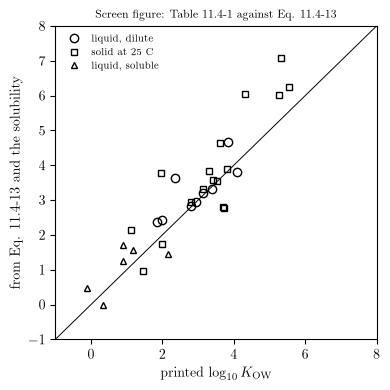

In [6]:
# Turn the residual around: for a solid, the excess of the prediction over the measured
# log K_OW is 0.806 log10(f_L/f_S), so the fugacity ratio follows from the table alone.
solid = ~liquid & (x_sat < 1e-3)
implied = 10.0 ** (-residual[solid] / 0.806)        # f_S/f_L

print("  Solid solutes: the fugacity ratio implied by the residual")
print(f"  {'substance':24s} {'T_melt':>7s} {'resid':>7s} {'implied f_S/f_L':>16s}")
for nm, tm, r, f in zip(name[solid], T_melt[solid], residual[solid], implied):
    flag = ""
    if f > 1.0:
        flag = "   impossible for a solid"
    elif tm < 40 and f < 0.05:
        flag = "   far too small for a solid 6 C above 25 C"
    print(f"  {nm:24s} {tm:7.1f} {r:+7.2f} {f:16.3f}{flag}")

print(f"\n  {(implied < 1).sum()} of {solid.sum()} come out below 1, as a solid's")
print(f"  fugacity ratio must, and they order roughly by melting point. The two that do")
print(f"  not are 2,4,5- and 2,4,6-trichlorophenol, which hydrogen-bond to water and are")
print(f"  therefore not 'very hydrophobic' -- the class Eq. 11.4-13 was correlated for.")
print(f"\n  And 2-cresol fails a third time here: melting at 30.9 C it cannot have a")
print(f"  fugacity ratio of 0.005, which is a solid 150 C above room temperature. Three")
print(f"  independent tests point at the same cell.")

fig, ax = plt.subplots(figsize=(4.0, 4.0))
ax.plot([-1, 8], [-1, 8], "-", color="k", lw=0.7)
ax.plot(log_kow[usable], predicted[usable], "o", mfc="none", mec="k", ms=6,
        label="liquid, dilute")
ax.plot(log_kow[~liquid], predicted[~liquid], "s", mfc="none", mec="k", ms=4,
        label="solid at 25 C")
ax.plot(log_kow[liquid & ~usable], predicted[liquid & ~usable], "^", mfc="none",
        mec="k", ms=4, label="liquid, soluble")
ax.set_xlabel(r"printed $\log_{10} K_{\rm OW}$")
ax.set_ylabel(r"from Eq. 11.4-13 and the solubility")
ax.set_xlim(-1, 8); ax.set_ylim(-1, 8)
ax.legend(fontsize=7, loc="upper left", frameon=False)
ax.set_title("Screen figure: Table 11.4-1 against Eq. 11.4-13", fontsize=8)
fig.tight_layout()
plt.show()


## What the table shows, now that it has been used

Table 11.4-1 is printed as reference data and never touched. Reading it as a set of
*constraints* instead turns up six cells that are inconsistent with their own rows by
factors of ten to a hundred thousand, and it turns the melting-point column from a
curiosity into the thing that decides whether a solubility can be read as an activity
coefficient at all.

It also puts a number on the correlation the section offers: a factor of two in
$K_{\rm OW}$ for the chemicals it was built for, and an order of magnitude for a
high-melting solid if the fugacity ratio is left out. Both of those are the sort of thing
a reader can only learn by running the numbers, which is what the table has never had
done to it in five editions.

## Your turn

1. The molecular weights above were supplied from formulas. Change one of them by 10 %
   and watch which rows of the identity test move. Then explain why the test is a check
   on the molecular weights as well as on the table.
2. Redo the solid rows properly. Look up $\Delta_{\rm fus}H$ for naphthalene, lindane and
   hexachlorobenzene, compute $f^{\rm S}/f^{\rm L}$ from Eq. 9.7-8a, and see whether the
   predicted $\log_{10}K_{\rm OW}$ moves onto the diagonal.
3. Problem 11.4-5(b) names five substances: aniline, 1,2-dichlorobenzene, ethylbenzene,
   naphthalene and styrene, "all of which are above their melting point." Check that
   claim against the table's own melting-point column.
4. Fit your own correlation. Take the rows where $1/x^{\rm sat}$ is defensible, regress
   $\log_{10}K_{\rm OW}$ on $\log_{10}\gamma^{W,\infty}$, and compare your slope and
   intercept with Eq. 11.4-13's $-0.486$ and $0.806$. How many points does it take before
   the slope is determined to better than 10 %?
5. Eq. 11.4-13 has a slope of 0.806 where the derivation in Eq. 11.4-12 gives exactly 1.
   What physical difference between solutes would make the slope less than one? (Hint:
   what does $\gamma_i^{O,\infty}$ do as the solute gets more hydrophobic?)